# Poisson process (event arrivals)

A Poisson process models *event counts over time* — arrivals at a queue, clicks, failures — where events occur independently at a constant average rate. It is the baseline against which bursty or self-exciting arrival patterns are compared.

::: {.callout-note}
## The model

$$y_t \sim \mathrm{Poisson}(\lambda), \qquad \mathbb{E}[y_t] = \mathrm{Var}(y_t) = \lambda$$

Events arrive independently at rate `lambda` per unit time, so counts in disjoint windows are independent and Poisson-distributed. The result is the memoryless benchmark: no clustering, no correlation between successive intervals.
:::

In [ ]:
import polars as pl
import matplotlib.pyplot as plt

from synforecast.generators import PoissonProcessGenerator

## 1. Basic event counts (non-cumulative)

Generate hourly event counts with an average rate of 3 events per hour.

In [ ]:
basic_params = {
    "min_length": 50,
    "max_length": 50,
    "freq": "h",
    "lambda_rate": 3.0,
    "cumulative": False,
    "seed": 42,
}

basic_gen = PoissonProcessGenerator(engine="polars", **basic_params)
basic_df = basic_gen.generate(n_series=1)

print(f"Generated {len(basic_df)} hourly event counts (lambda={basic_params['lambda_rate']})")
print(f"Statistics: Mean={basic_df['y'].mean():.4f}, Total Events={basic_df['y'].sum():.0f}")
basic_df.head(10)

Generated 50 hourly event counts (lambda=3.0)
Statistics: Mean=2.9200, Total Events=146


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,1.0
"""0""",2000-01-01 01:00:00,3.0
"""0""",2000-01-01 02:00:00,5.0
"""0""",2000-01-01 03:00:00,2.0
"""0""",2000-01-01 04:00:00,1.0
"""0""",2000-01-01 05:00:00,5.0
"""0""",2000-01-01 06:00:00,6.0
"""0""",2000-01-01 07:00:00,6.0
"""0""",2000-01-01 08:00:00,1.0


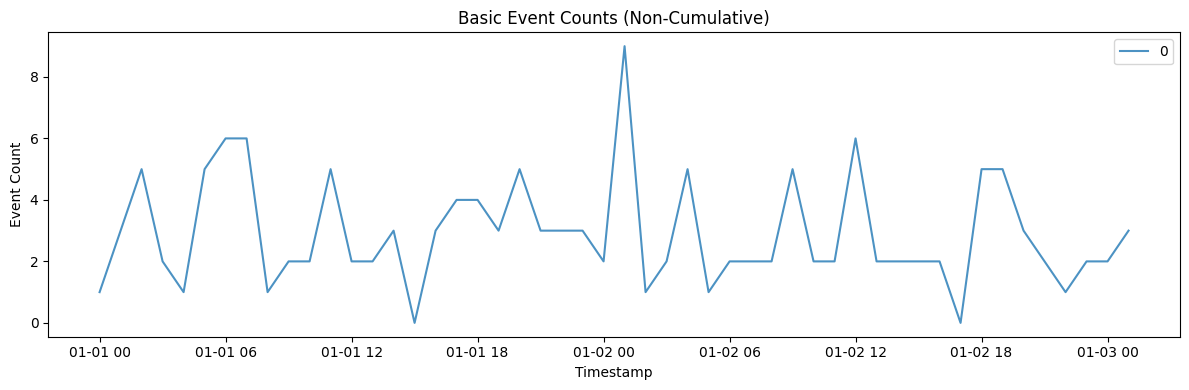

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in basic_df["unique_id"].unique().to_list():
    series = basic_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Event Count")
ax.set_title("Basic Event Counts (Non-Cumulative)")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Cumulative event counts

The same process but with cumulative counting — useful for modeling total arrivals over time.

In [ ]:
cumulative_params = {
    "min_length": 50,
    "max_length": 50,
    "freq": "h",
    "lambda_rate": 3.0,
    "cumulative": True,
    "seed": 42,
}

cumulative_gen = PoissonProcessGenerator(engine="polars", **cumulative_params)
cumulative_df = cumulative_gen.generate(n_series=1)

print(f"Generated {len(cumulative_df)} hourly cumulative counts")
print(f"Final cumulative count: {cumulative_df['y'].tail(1).item():.0f}")
cumulative_df.head(10)

Generated 50 hourly cumulative counts
Final cumulative count: 146


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,1.0
"""0""",2000-01-01 01:00:00,4.0
"""0""",2000-01-01 02:00:00,9.0
"""0""",2000-01-01 03:00:00,11.0
"""0""",2000-01-01 04:00:00,12.0
"""0""",2000-01-01 05:00:00,17.0
"""0""",2000-01-01 06:00:00,23.0
"""0""",2000-01-01 07:00:00,29.0
"""0""",2000-01-01 08:00:00,30.0


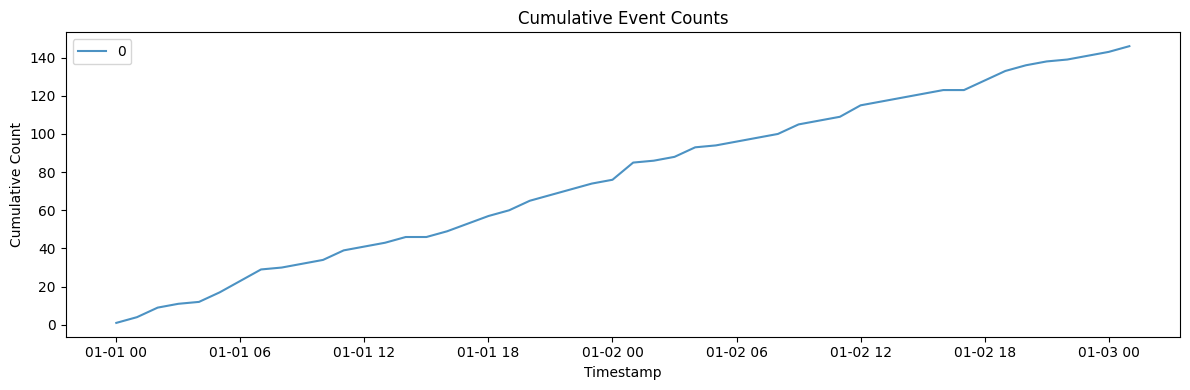

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in cumulative_df["unique_id"].unique().to_list():
    series = cumulative_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Cumulative Count")
ax.set_title("Cumulative Event Counts")
ax.legend()
plt.tight_layout()
plt.show()

## 3. High rate events (busy system)

A high lambda rate of 10 events per hour simulates a busy system.

In [ ]:
high_rate_params = {
    "min_length": 50,
    "max_length": 50,
    "freq": "h",
    "lambda_rate": 10.0,
    "cumulative": False,
    "seed": 42,
}

high_rate_gen = PoissonProcessGenerator(engine="polars", **high_rate_params)
high_rate_df = high_rate_gen.generate(n_series=1)

print(f"Generated {len(high_rate_df)} hourly counts with high event rate")
print(f"Statistics: Mean={high_rate_df['y'].mean():.4f}, Total Events={high_rate_df['y'].sum():.0f}")
high_rate_df.head(10)

Generated 50 hourly counts with high event rate
Statistics: Mean=9.8400, Total Events=492


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,8.0
"""0""",2000-01-01 01:00:00,9.0
"""0""",2000-01-01 02:00:00,18.0
"""0""",2000-01-01 03:00:00,5.0
"""0""",2000-01-01 04:00:00,10.0
"""0""",2000-01-01 05:00:00,6.0
"""0""",2000-01-01 06:00:00,13.0
"""0""",2000-01-01 07:00:00,12.0
"""0""",2000-01-01 08:00:00,11.0


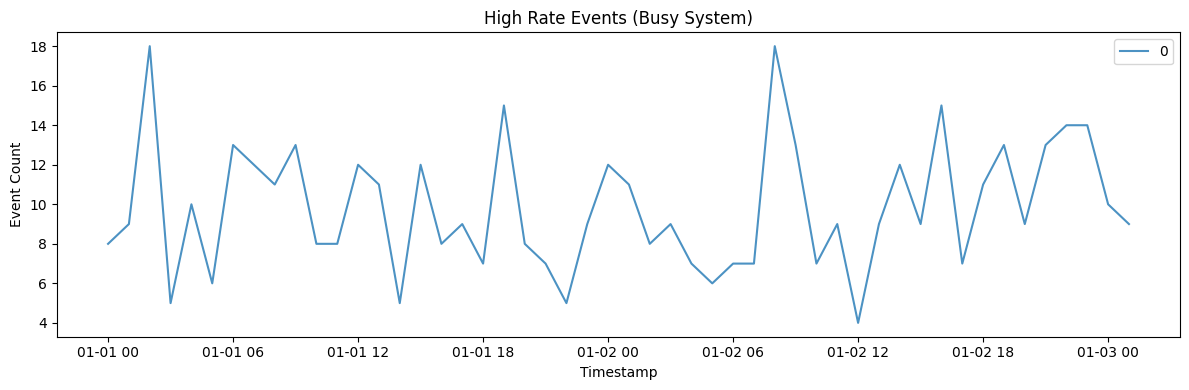

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in high_rate_df["unique_id"].unique().to_list():
    series = high_rate_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Event Count")
ax.set_title("High Rate Events (Busy System)")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Low rate events (rare events)

A low lambda of 0.5 produces mostly zeros with occasional events.

In [ ]:
low_rate_params = {
    "min_length": 100,
    "max_length": 100,
    "freq": "h",
    "lambda_rate": 0.5,
    "cumulative": False,
    "seed": 42,
}

low_rate_gen = PoissonProcessGenerator(engine="polars", **low_rate_params)
low_rate_df = low_rate_gen.generate(n_series=1)

print(f"Generated {len(low_rate_df)} hourly counts with rare events")
print(f"Statistics: Mean={low_rate_df['y'].mean():.4f}, Total Events={low_rate_df['y'].sum():.0f}")
low_rate_df.head(20)

Generated 100 hourly counts with rare events
Statistics: Mean=0.5800, Total Events=58


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,0.0
"""0""",2000-01-01 01:00:00,0.0
"""0""",2000-01-01 02:00:00,2.0
"""0""",2000-01-01 03:00:00,0.0
"""0""",2000-01-01 04:00:00,1.0
…,…,…
"""0""",2000-01-01 15:00:00,0.0
"""0""",2000-01-01 16:00:00,2.0
"""0""",2000-01-01 17:00:00,2.0


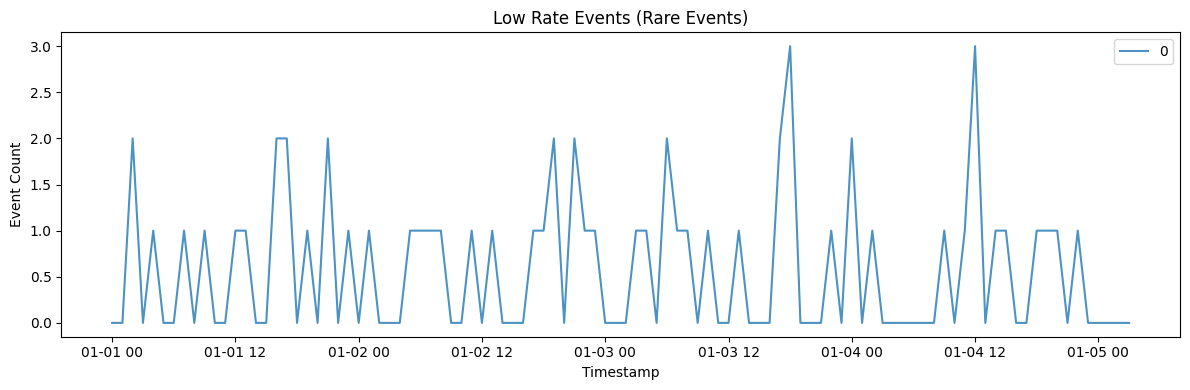

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in low_rate_df["unique_id"].unique().to_list():
    series = low_rate_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Event Count")
ax.set_title("Low Rate Events (Rare Events)")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Daily event counts

Change the frequency to daily with 5 events per day on average.

In [ ]:
daily_params = {
    "min_length": 100,
    "max_length": 100,
    "freq": "D",
    "lambda_rate": 5.0,
    "cumulative": False,
    "seed": 42,
}

daily_gen = PoissonProcessGenerator(engine="polars", **daily_params)
daily_df = daily_gen.generate(n_series=1)

print(f"Generated {len(daily_df)} daily event counts")
print(f"Statistics: Mean={daily_df['y'].mean():.4f}, Total Events={daily_df['y'].sum():.0f}")
daily_df.head(10)

Generated 100 daily event counts
Statistics: Mean=4.9400, Total Events=494


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,2.0
"""0""",2000-01-02 00:00:00,5.0
"""0""",2000-01-03 00:00:00,5.0
"""0""",2000-01-04 00:00:00,6.0
"""0""",2000-01-05 00:00:00,9.0
"""0""",2000-01-06 00:00:00,6.0
"""0""",2000-01-07 00:00:00,4.0
"""0""",2000-01-08 00:00:00,6.0
"""0""",2000-01-09 00:00:00,3.0


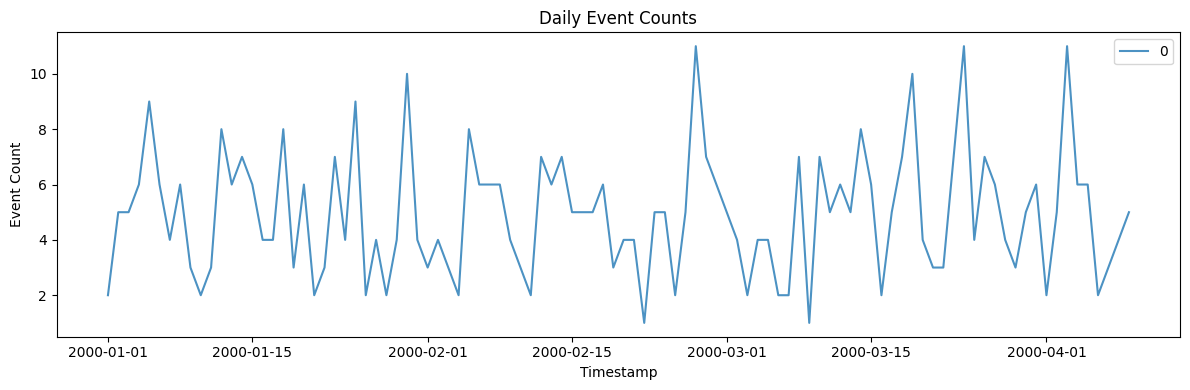

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in daily_df["unique_id"].unique().to_list():
    series = daily_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Event Count")
ax.set_title("Daily Event Counts")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Multiple Poisson processes

Generate multiple independent processes in one call.

In [ ]:
multi_params = {
    "min_length": 50,
    "max_length": 50,
    "freq": "h",
    "lambda_rate": 3.0,
    "cumulative": False,
    "seed": 42,
}

multi_gen = PoissonProcessGenerator(engine="polars", **multi_params)
multi_df = multi_gen.generate(n_series=4)

print(f"Generated 4 different Poisson processes with {len(multi_df)} total observations")
print(f"Overall Statistics: Mean={multi_df['y'].mean():.4f}, Total Events={multi_df['y'].sum():.0f}")
multi_df.filter(pl.col("unique_id") == "0").head(10)

Generated 4 different Poisson processes with 200 total observations
Overall Statistics: Mean=2.9900, Total Events=598


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,1.0
"""0""",2000-01-01 01:00:00,3.0
"""0""",2000-01-01 02:00:00,5.0
"""0""",2000-01-01 03:00:00,2.0
"""0""",2000-01-01 04:00:00,1.0
"""0""",2000-01-01 05:00:00,5.0
"""0""",2000-01-01 06:00:00,6.0
"""0""",2000-01-01 07:00:00,6.0
"""0""",2000-01-01 08:00:00,1.0


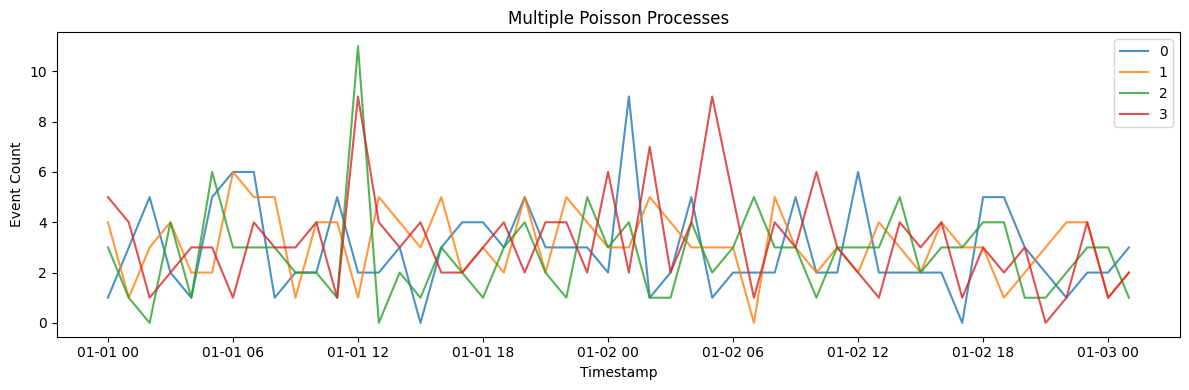

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in multi_df["unique_id"].unique().to_list():
    series = multi_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Event Count")
ax.set_title("Multiple Poisson Processes")
ax.legend()
plt.tight_layout()
plt.show()

::: {.callout-tip}
## Related generators

- [Hawkes process](hawkes_process) — arrivals that cluster because each event raises the rate.
- [INAR](../statistical/inar) — autocorrelated integer counts.

Rate parameters are in the [generator reference](https://github.com/Nixtla/synforecast/blob/main/GENERATORS.md).
:::